In [1]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION'

In [3]:
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True  # Optimize backend performance
torch.cuda.reset_peak_memory_stats()

In [4]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths
root_dir = '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET'
train_images_dir = os.path.join(root_dir, 'train/images')
train_masks_dir = os.path.join(root_dir, 'train/masks')
val_images_dir = os.path.join(root_dir, 'val/images')
val_masks_dir = os.path.join(root_dir, 'val/masks')

# Custom Dataset
class RooftopDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = sorted(os.listdir(image_dir))
        self.transform = transform
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.image_filenames[idx])
        
        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = mask.astype(np.float32) / 255.0
        
        if self.transform:
            image = self.transform(image)
            mask = transforms.ToTensor()(mask).unsqueeze(0)  # Ensure mask shape [1, H, W]
        
        return image, mask.squeeze(0)  # Ensure mask shape [H, W]

# Transformations
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((1024, 1024)),
    transforms.ToTensor()
])

# Load datasets
train_dataset = RooftopDataset(train_images_dir, train_masks_dir, transform)
val_dataset = RooftopDataset(val_images_dir, val_masks_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

# U-Net Model
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU()
            )
        
        self.encoder = nn.ModuleList([
            conv_block(3, 16),
            conv_block(16, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256)
        ])
        
        self.pool = nn.MaxPool2d(2)
        
        self.upconv = nn.ModuleList([
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        ])
        
        self.decoder = nn.ModuleList([
            conv_block(256, 128),
            conv_block(128, 64),
            conv_block(64, 32),
            conv_block(32, 16)
        ])
        
        self.final_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        enc_outs = []
        for enc in self.encoder:
            x = enc(x)
            enc_outs.append(x)
            x = self.pool(x)
        
        for i in range(4):
            x = self.upconv[i](x)
            enc_out = enc_outs[-(i+2)]
            if x.shape[2:] != enc_out.shape[2:]:
                x = nn.functional.interpolate(x, size=enc_out.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, enc_out], dim=1)
            x = self.decoder[i](x)
        
        return torch.sigmoid(self.final_conv(x))

# Training Setup
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training Loop
def train(model, train_loader, val_loader, epochs=50):
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)  # Ensure correct shape [B, 1, H, W]
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")
    
    torch.save(model.state_dict(), "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/unet/unet_rooftop_50_2.pth")
    torch.save(model, "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/unet/full_unet_rooftop_50_2.pth")
    
    print("Model saved!")

train(model, train_loader, val_loader,epochs=50)

Using device: cuda
Epoch 1/50, Loss: 0.3332
Epoch 2/50, Loss: 0.1860
Epoch 3/50, Loss: 0.1683
Epoch 4/50, Loss: 0.1466
Epoch 5/50, Loss: 0.1356
Epoch 6/50, Loss: 0.1300
Epoch 7/50, Loss: 0.1254
Epoch 8/50, Loss: 0.1212
Epoch 9/50, Loss: 0.1176
Epoch 10/50, Loss: 0.1142
Epoch 11/50, Loss: 0.1107
Epoch 12/50, Loss: 0.1078
Epoch 13/50, Loss: 0.1051
Epoch 14/50, Loss: 0.1027
Epoch 15/50, Loss: 0.1006
Epoch 16/50, Loss: 0.0985
Epoch 17/50, Loss: 0.0967
Epoch 18/50, Loss: 0.0953
Epoch 19/50, Loss: 0.0941
Epoch 20/50, Loss: 0.0932
Epoch 21/50, Loss: 0.0921
Epoch 22/50, Loss: 0.0905
Epoch 23/50, Loss: 0.0900
Epoch 24/50, Loss: 0.0889
Epoch 25/50, Loss: 0.0885
Epoch 26/50, Loss: 0.0876
Epoch 27/50, Loss: 0.0867
Epoch 28/50, Loss: 0.0868
Epoch 29/50, Loss: 0.0854
Epoch 30/50, Loss: 0.0848
Epoch 31/50, Loss: 0.0848
Epoch 32/50, Loss: 0.0838
Epoch 33/50, Loss: 0.0832
Epoch 34/50, Loss: 0.0827
Epoch 35/50, Loss: 0.0824
Epoch 36/50, Loss: 0.0818
Epoch 37/50, Loss: 0.0813
Epoch 38/50, Loss: 0.0809
Ep

In [5]:
# Evaluation

def evaluate(model, val_loader):
    model.eval()
    iou_scores = []
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).float()
            
            intersection = (preds * masks).sum()
            union = (preds + masks).sum() - intersection
            iou = intersection / (union + 1e-6)
            iou_scores.append(iou.item())
    
    print(f"Mean IoU Score: {np.mean(iou_scores):.4f}")
    return iou_scores


iou_score = evaluate(model, val_loader)

Mean IoU Score: 0.5886


In [6]:
losses = [0.5332
,0.4198
,0.3664
,0.3346
,0.3108
,0.2978
,0.2890
,0.2731
,0.2646
,0.2532
,0.2452
,0.2408
,0.2324
,0.2273
,0.2210
,0.2170
,0.2125
,0.2101
,0.2022
,0.2009
,0.1984
,0.1936
,0.1892
,0.1859
,0.1819
,0.1789
,0.1762
,0.1745
,0.1722
,0.1715
,0.1700
,0.1677
,0.1638
,0.1607
,0.1609
,0.1626
,0.1561
,0.1570
,0.1524
,0.1505
,0.1497
,0.1478
,0.1440
,0.1439
,0.1426
,0.1379
,0.1385
,0.1389,0.1360,0.1330]

In [7]:
len(losses)

50

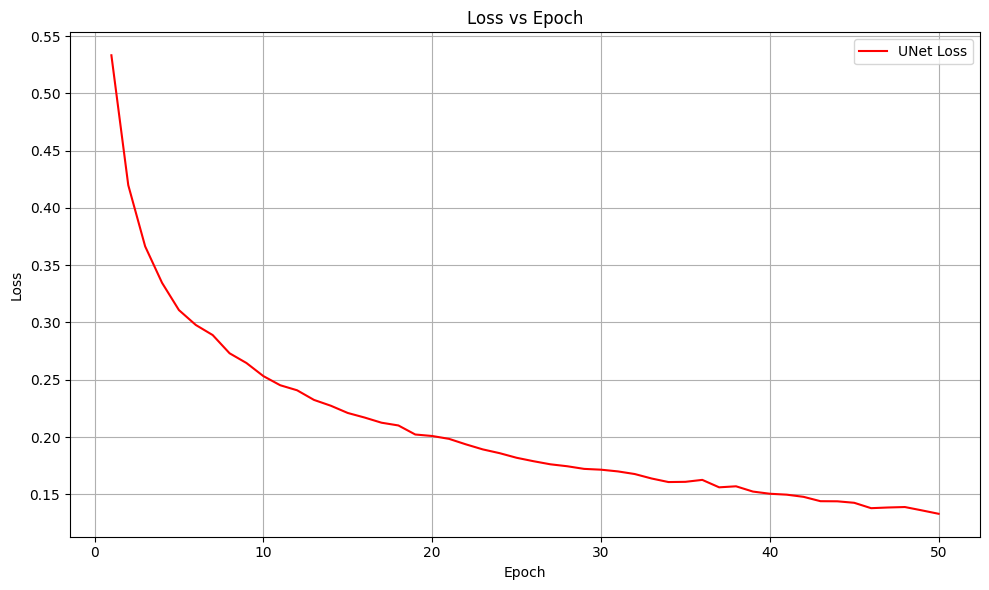

In [8]:
import matplotlib.pyplot as plt

unet_loss = losses
epochs = list(range(1,51))

plt.figure(figsize=(10, 6))
# plt.plot(epochs, maskrcnn_loss, label='Mask R-CNN Loss', color='green')
plt.plot(epochs, unet_loss, label='UNet Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig('/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/unet/loss_vs_epoch_UNET_50.png')
plt.tight_layout()
plt.show()